In [722]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Ajustes opcionais para melhorar visualização no notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [723]:
# ============================================================
# 2. DEFINIR O CAMINHO DOS DADOS
# ============================================================

# Pasta onde estão os arquivos CSV
data_path = Path("data")

# ============================================================
# 3. FUNÇÃO PARA CARREGAR TODOS OS CSVs
# ============================================================

def load_data(path):
    """
    Lê todos os CSVs da pasta e retorna um dicionário de DataFrames.
    """
    dfs = {}

    for file in path.glob("*.csv"):
        # Exemplo:
        # olist_customers_dataset.csv -> customers
        # olist_order_items_dataset.csv -> order_items
        name = file.stem.replace("olist_", "").replace("_dataset", "")
        dfs[name] = pd.read_csv(file)
        print(f"Tabela '{name}' carregada: {dfs[name].shape}")

    return dfs

# ============================================================
# 4. CARREGAR OS DADOS
# ============================================================

dfs = load_data(data_path)

print("Tabelas carregadas:", dfs.keys())

customers_df = dfs["customers"]
orders_df = dfs["orders"]
order_items_df = dfs["order_items"]

Tabela 'customers' carregada: (99441, 5)
Tabela 'geolocation' carregada: (1000163, 5)
Tabela 'orders' carregada: (99441, 8)
Tabela 'order_items' carregada: (112650, 7)
Tabela 'order_payments' carregada: (103886, 5)
Tabela 'order_reviews' carregada: (99224, 7)
Tabela 'products' carregada: (32951, 9)
Tabela 'sellers' carregada: (3095, 4)
Tabela 'product_category_name_translation' carregada: (71, 2)
Tabelas carregadas: dict_keys(['customers', 'geolocation', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers', 'product_category_name_translation'])


In [724]:
# ============================================================
# 5. INSPEÇÃO INICIAL
# ============================================================

print("\n--- CUSTOMERS ---")
display(customers_df.head())

print("\n--- ORDERS ---")
display(orders_df.head())

print("\n--- ORDER ITEMS ---")
display(order_items_df.head())


--- CUSTOMERS ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- ORDERS ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- ORDER ITEMS ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [725]:
# ============================================================
# 6. AGREGAR ORDER_ITEMS NO NÍVEL DO PEDIDO
# ============================================================

# IMPORTANTE:
# order_items está no nível do item.
# Um pedido pode ter 1, 2, 3... vários itens.
#
# Para analisar rentabilidade e logística corretamente,
# vamos consolidar no nível do pedido (order_id).

order_items_agg = (
    order_items_df
    .groupby("order_id", as_index=False)
    .agg(
        receita_total=("price", "sum"),
        frete_total=("freight_value", "sum"),
        quantidade_itens=("order_item_id", "count")
    )
)

# Criar uma proxy de rentabilidade por pedido
# Observação:
# isso NÃO é lucro real, é uma aproximação analítica.
order_items_agg["rentabilidade_proxy"] = (
    order_items_agg["receita_total"] - order_items_agg["frete_total"]
)

print("\n--- ORDER ITEMS AGREGADO POR PEDIDO ---")
display(order_items_agg.head())


--- ORDER ITEMS AGREGADO POR PEDIDO ---


,order_id,receita_total,frete_total,quantidade_itens,rentabilidade_proxy
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,45.61
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,219.97
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,181.13
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,0.20
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,181.76


In [726]:
# ============================================================
# 7. JUNTAR TABELAS NO NÍVEL DO PEDIDO
# ============================================================

# Primeiro: orders + customers
df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

# Depois: resultado + order_items agregado
df = df.merge(
    order_items_agg,
    on="order_id",
    how="left"
)

print("\nDimensão após joins:", df.shape)
display(df.head())


Dimensão após joins: (99441, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,receita_total,frete_total,quantidade_itens,rentabilidade_proxy
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,21.27
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,95.94
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,140.68
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,17.80
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,11.18


In [727]:
# ============================================================
# 8. CONVERTER COLUNAS DE DATA
# ============================================================

# Transformar strings em datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  str           
 11  customer_state            

In [728]:
# ============================================================
# 9. CRIAR MÉTRICAS DE LOGÍSTICA
# ============================================================

# 9.1 Tempo de entrega ao cliente (compra -> entrega)
df["tempo_entrega_dias"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

# 9.2 Tempo até postagem/coleta pela transportadora (compra -> carrier)
df["tempo_postagem_dias"] = (
    df["order_delivered_carrier_date"] - df["order_purchase_timestamp"]
).dt.days

# 9.3 Atraso em relação à data estimada
# Valor positivo = entregou depois do estimado
# Valor negativo = entregou antes do estimado
df["atraso_vs_estimado_dias"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,receita_total,frete_total,quantidade_itens,rentabilidade_proxy,tempo_entrega_dias,tempo_postagem_dias,atraso_vs_estimado_dias
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,21.27,8.0,2.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,95.94,13.0,1.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,140.68,9.0,0.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,17.80,13.0,3.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,11.18,2.0,0.0,-10.0


In [729]:
# ============================================================
# 10. MAPEAR ESTADO PARA REGIÃO
# ============================================================

# Como queremos analisar por região,
# vamos transformar as UFs em macrorregiões do Brasil.

mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

df["regiao"] = df["customer_state"].map(mapa_regioes)

display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,receita_total,frete_total,quantidade_itens,rentabilidade_proxy,tempo_entrega_dias,tempo_postagem_dias,atraso_vs_estimado_dias,regiao
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,21.27,8.0,2.0,-8.0,Sudeste
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,95.94,13.0,1.0,-6.0,Nordeste
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,140.68,9.0,0.0,-18.0,Centro-Oeste
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,17.80,13.0,3.0,-13.0,Nordeste
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,11.18,2.0,0.0,-10.0,Sudeste


In [730]:
# ============================================================
# 11. LIMPEZA DOS DADOS
# ============================================================

# Para esta análise, queremos pedidos:
# - com status entregue
# - com datas válidas
# - com tempo de entrega não negativo
# - com receita/frete válidos
# - com região identificada

print("\nDimensão antes limpeza:", df.shape)

df_limpo = df.copy()

# Focar apenas em pedidos entregues
df_limpo = df_limpo[df_limpo["order_status"] == "delivered"]

# Remover nulos das variáveis principais
colunas_essenciais = [
    "tempo_entrega_dias",
    "rentabilidade_proxy",
    "receita_total",
    "frete_total",
    "regiao"
]

for col in colunas_essenciais:
    df_limpo = df_limpo[df_limpo[col].notna()]

# Remover tempos negativos
df_limpo = df_limpo[df_limpo["tempo_entrega_dias"] >= 0]

# Remover casos com receita total <= 0
df_limpo = df_limpo[df_limpo["receita_total"] > 0]

print("\nDimensão após limpeza:", df_limpo.shape)





Dimensão antes limpeza: (99441, 20)

Dimensão após limpeza: (96470, 20)


In [731]:
# ============================================================
# 12. CRIAR MÉTRICAS PERCENTUAIS ÚTEIS
# ============================================================

# Margem logística aproximada (%)
# Quanto sobra da receita depois de descontar frete
df_limpo["margem_proxy_pct"] = (
    df_limpo["rentabilidade_proxy"] / df_limpo["receita_total"]
) * 100

# Indicador binário: entrega no prazo?
df_limpo["entrega_no_prazo"] = df_limpo["atraso_vs_estimado_dias"] <= 0

display(df_limpo.head())


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,receita_total,frete_total,quantidade_itens,rentabilidade_proxy,tempo_entrega_dias,tempo_postagem_dias,atraso_vs_estimado_dias,regiao,margem_proxy_pct,entrega_no_prazo
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,21.27,8.0,2.0,-8.0,Sudeste,70.923641,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,95.94,13.0,1.0,-6.0,Nordeste,80.825611,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,140.68,9.0,0.0,-18.0,Centro-Oeste,87.979987,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,17.80,13.0,3.0,-13.0,Nordeste,39.555556,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,11.18,2.0,0.0,-10.0,Sudeste,56.180905,True


In [732]:
# ============================================================
# 13. ANÁLISE POR REGIÃO
# ============================================================

# Aqui vamos calcular métricas por região:
# - tempo médio de entrega
# - mediana do tempo (mais robusta)
# - rentabilidade média
# - margem percentual média
# - taxa de entrega no prazo
# - quantidade de pedidos
# - receita total

analise_regiao = (
    df_limpo
    # Agrupar por região
    .groupby("regiao", as_index=False)
    
    # Calcular métricas relevantes
    .agg(
        # Número de pedidos únicos
        pedidos=("order_id", "nunique"),
        
        # Receita total agregada
        receita_total=("receita_total", "sum"),
        
        # Tempo médio de entrega (sensível a outliers)
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        
        # Mediana (mais robusta para distribuição assimétrica)
        tempo_entrega_mediano=("tempo_entrega_dias", "median"),
        
        # Desvio padrão (mede variabilidade/logística)
        tempo_std=("tempo_entrega_dias", "std"),
        
        # Rentabilidade média por pedido
        rentabilidade_media=("rentabilidade_proxy", "mean"),
        
        # Margem percentual média
        margem_media_pct=("margem_proxy_pct", "mean"),
        
        # Taxa de entrega no prazo (proporção)
        taxa_no_prazo=("entrega_no_prazo", "mean")
    )
)

# Transformar taxa_no_prazo em percentual
analise_regiao["taxa_no_prazo"] = analise_regiao["taxa_no_prazo"] * 100

print("\n--- ANÁLISE POR REGIÃO ---")
display(analise_regiao.sort_values("tempo_entrega_medio"))


--- ANÁLISE POR REGIÃO ---


,regiao,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
3,Sudeste,66193,8647339.39,10.288701,8.0,8.509714,110.800377,72.266582,93.884550
4,Sul,13813,1901794.11,13.557446,12.0,8.437792,113.333298,66.478474,94.099761
0,Centro-Oeste,5624,846956.70,14.563656,13.0,8.393141,124.108416,65.593855,93.474395
1,Nordeste,9044,1497083.78,19.536046,17.0,12.254414,129.547130,56.337514,87.284387
2,Norte,1796,327074.95,22.144209,20.0,13.100504,140.763268,51.100697,91.425390


In [733]:
# ============================================================
# 14. NORMALIZAR MÉTRICAS PARA CRIAR UM SCORE COMBINADO
# ============================================================

# A análise combina duas dimensões:
# - menor tempo de entrega
# - maior rentabilidade
#
# Vamos criar um score para apoiar a resposta.
#
# Regras:
# - menor tempo = melhor
# - maior rentabilidade = melhor

analise_score = analise_regiao.copy()

# Normalização min-max invertida para tempo:
# menor tempo => score maior
analise_score["score_tempo"] = (
    analise_score["tempo_entrega_medio"].max() - analise_score["tempo_entrega_medio"]
) / (
    analise_score["tempo_entrega_medio"].max() - analise_score["tempo_entrega_medio"].min()
)

# Normalização min-max para rentabilidade:
# maior rentabilidade => score maior
analise_score["score_rentabilidade"] = (
    analise_score["rentabilidade_media"] - analise_score["rentabilidade_media"].min()
) / (
    analise_score["rentabilidade_media"].max() - analise_score["rentabilidade_media"].min()
)

# Score final ponderado
# Aqui estamos dando pesos iguais:
# 50% tempo de entrega
# 50% rentabilidade
analise_score["score_final"] = (
    0.5 * analise_score["score_tempo"] +
    0.5 * analise_score["score_rentabilidade"]
)

# Ordenar do melhor para o pior
analise_score = analise_score.sort_values("score_final", ascending=False)

print("\n--- RANKING FINAL POR REGIÃO ---")
print("Observação: a rentabilidade utilizada é uma proxy baseada em receita menos frete.")
display(analise_score)


--- RANKING FINAL POR REGIÃO ---
Observação: a rentabilidade utilizada é uma proxy baseada em receita menos frete.


,regiao,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo,score_tempo,score_rentabilidade,score_final
0,Centro-Oeste,5624,846956.70,14.563656,13.0,8.393141,124.108416,65.593855,93.474395,0.639412,0.444151,0.541781
2,Norte,1796,327074.95,22.144209,20.0,13.100504,140.763268,51.100697,91.425390,0.000000,1.000000,0.500000
3,Sudeste,66193,8647339.39,10.288701,8.0,8.509714,110.800377,72.266582,93.884550,1.000000,0.000000,0.500000
1,Nordeste,9044,1497083.78,19.536046,17.0,12.254414,129.547130,56.337514,87.284387,0.219996,0.625666,0.422831
4,Sul,13813,1901794.11,13.557446,12.0,8.437792,113.333298,66.478474,94.099761,0.724285,0.084535,0.404410


In [734]:
# ============================================================
# 15. IDENTIFICAR A MELHOR REGIÃO
# ============================================================

melhor_regiao = analise_score.iloc[0]

print("\nMelhor região considerando menor tempo de entrega e maior rentabilidade:")
print(f"Região: {melhor_regiao['regiao']}")
print(f"Pedidos: {int(melhor_regiao['pedidos'])}")
print(f"Receita total: {melhor_regiao['receita_total']:.2f}")
print(f"Tempo médio de entrega: {melhor_regiao['tempo_entrega_medio']:.2f} dias")
print(f"Tempo mediano de entrega: {melhor_regiao['tempo_entrega_mediano']:.2f} dias")
print(f"Rentabilidade média: {melhor_regiao['rentabilidade_media']:.2f}")
print(f"Margem média (%): {melhor_regiao['margem_media_pct']:.2f}%")
print(f"Taxa de entrega no prazo: {melhor_regiao['taxa_no_prazo']:.2f}%")
print(f"Score final: {melhor_regiao['score_final']:.4f}")


Melhor região considerando menor tempo de entrega e maior rentabilidade:
Região: Centro-Oeste
Pedidos: 5624
Receita total: 846956.70
Tempo médio de entrega: 14.56 dias
Tempo mediano de entrega: 13.00 dias
Rentabilidade média: 124.11
Margem média (%): 65.59%
Taxa de entrega no prazo: 93.47%
Score final: 0.5418


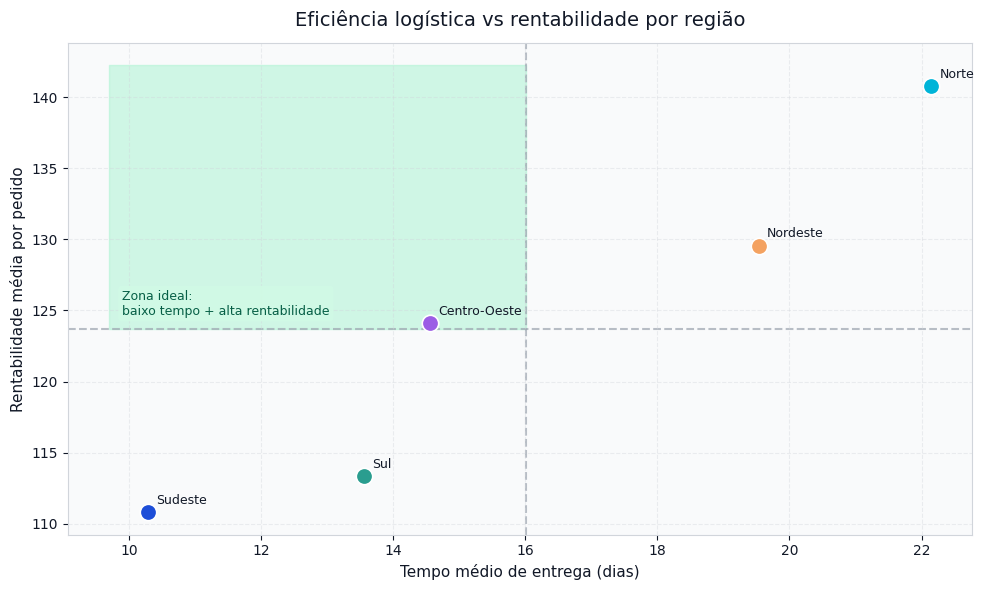


O gráfico evidencia a relação entre tempo médio de entrega e rentabilidade por região, permitindo identificar possíveis padrões de trade-off entre eficiência logística e retorno financeiro.

Observa-se que a região Sudeste apresenta o menor tempo médio de entrega, indicando maior eficiência operacional, enquanto a região Norte se destaca pela maior rentabilidade média por pedido.

Esse comportamento sugere que regiões mais eficientes logisticamente não são, necessariamente, aquelas com maior retorno financeiro, indicando um possível trade-off entre agilidade na entrega e rentabilidade.

Dado que nenhuma região lidera simultaneamente nas duas dimensões analisadas, foi construído um score combinado, com pesos iguais para tempo de entrega e rentabilidade.

Com base nesse critério, a região Centro-Oeste apresenta o melhor desempenho geral, configurando-se como a região mais equilibrada sob a ótica logística e financeira.



In [735]:
# ============================================================
# 16. SCATTER PLOT: TEMPO X RENTABILIDADE POR REGIÃO
# ============================================================

# Paleta padrão por região.
# Cada região recebe uma cor fixa para manter consistência visual
# em todos os gráficos do projeto.
cores_regiao = {
    "Norte": "#00B4D8",
    "Nordeste": "#F4A261",
    "Centro-Oeste": "#9B5DE5",
    "Sudeste": "#1D4ED8",
    "Sul": "#2A9D8F"
}

# Cores do tema visual claro do projeto.
# Esse padrão melhora a leitura em relatório, apresentação e Power BI.
cor_figura = "#FFFFFF"   # fundo externo da figura
cor_fundo = "#F9FAFB"    # fundo interno do gráfico
cor_texto = "#111827"    # texto principal
cor_grid = "#D1D5DB"     # linhas de grade e bordas

# Criar figura e eixo.
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plotar os pontos por região
# ------------------------------------------------------------
# Cada ponto representa uma região.
# Eixo X: tempo médio de entrega
# Eixo Y: rentabilidade média por pedido
for _, row in analise_score.iterrows():
    ax.scatter(
        row["tempo_entrega_medio"],
        row["rentabilidade_media"],
        s=140,
        color=cores_regiao.get(row["regiao"], "#9CA3AF"),
        edgecolor="#FFFFFF",
        linewidth=1.2,
        zorder=3  # mantém os pontos acima da zona destacada
    )

# ------------------------------------------------------------
# Adicionar labels das regiões
# ------------------------------------------------------------
# Os nomes das regiões são adicionados próximos aos pontos
# para facilitar a leitura sem depender de legenda.
for _, row in analise_score.iterrows():
    ax.annotate(
        row["regiao"],
        (row["tempo_entrega_medio"], row["rentabilidade_media"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
        color=cor_texto,
        zorder=4
    )

# ------------------------------------------------------------
# Calcular linhas de referência
# ------------------------------------------------------------
# As médias ajudam a dividir o gráfico em quadrantes:
# - abaixo/acima da média de rentabilidade
# - abaixo/acima da média de tempo de entrega
media_tempo = analise_score["tempo_entrega_medio"].mean()
media_rent = analise_score["rentabilidade_media"].mean()

# Capturar limites do gráfico após plotar os pontos.
# Isso garante que a área verde seja desenhada corretamente.
y_min, y_max = ax.get_ylim()
x_min, x_max = ax.get_xlim()

# ------------------------------------------------------------
# Destacar zona ideal
# ------------------------------------------------------------
# A zona ideal representa o quadrante desejado:
# menor tempo de entrega + maior rentabilidade.
# zorder=0 garante que a área fique atrás dos pontos.
ax.fill_betweenx(
    [media_rent, y_max],
    x_min,
    media_tempo,
    color="#A7F3D0",
    alpha=0.5,
    zorder=0
)

# Texto explicativo da zona ideal.
ax.text(
    x=x_min + 0.2,
    y=media_rent + 1,
    s="Zona ideal:\nbaixo tempo + alta rentabilidade",
    fontsize=9,
    color="#065F46",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#D1FAE5",
        edgecolor="none",
        alpha=0.9
    ),
    zorder=5
)

# ------------------------------------------------------------
# Linhas médias
# ------------------------------------------------------------
# As linhas tracejadas indicam as médias das duas métricas.
ax.axvline(
    media_tempo,
    linestyle="--",
    color="#9CA3AF",
    alpha=0.7,
    zorder=1
)

ax.axhline(
    media_rent,
    linestyle="--",
    color="#9CA3AF",
    alpha=0.7,
    zorder=1
)

# ------------------------------------------------------------
# Título e rótulos dos eixos
# ------------------------------------------------------------
ax.set_title(
    "Eficiência logística vs rentabilidade por região",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Tempo médio de entrega (dias)", color=cor_texto)
ax.set_ylabel("Rentabilidade média por pedido", color=cor_texto)

# ------------------------------------------------------------
# Grade, eixos e bordas
# ------------------------------------------------------------
ax.grid(True, linestyle="--", alpha=0.4, color=cor_grid)
ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

print("""
O gráfico evidencia a relação entre tempo médio de entrega e rentabilidade por região, permitindo identificar possíveis padrões de trade-off entre eficiência logística e retorno financeiro.

Observa-se que a região Sudeste apresenta o menor tempo médio de entrega, indicando maior eficiência operacional, enquanto a região Norte se destaca pela maior rentabilidade média por pedido.

Esse comportamento sugere que regiões mais eficientes logisticamente não são, necessariamente, aquelas com maior retorno financeiro, indicando um possível trade-off entre agilidade na entrega e rentabilidade.

Dado que nenhuma região lidera simultaneamente nas duas dimensões analisadas, foi construído um score combinado, com pesos iguais para tempo de entrega e rentabilidade.

Com base nesse critério, a região Centro-Oeste apresenta o melhor desempenho geral, configurando-se como a região mais equilibrada sob a ótica logística e financeira.
""")

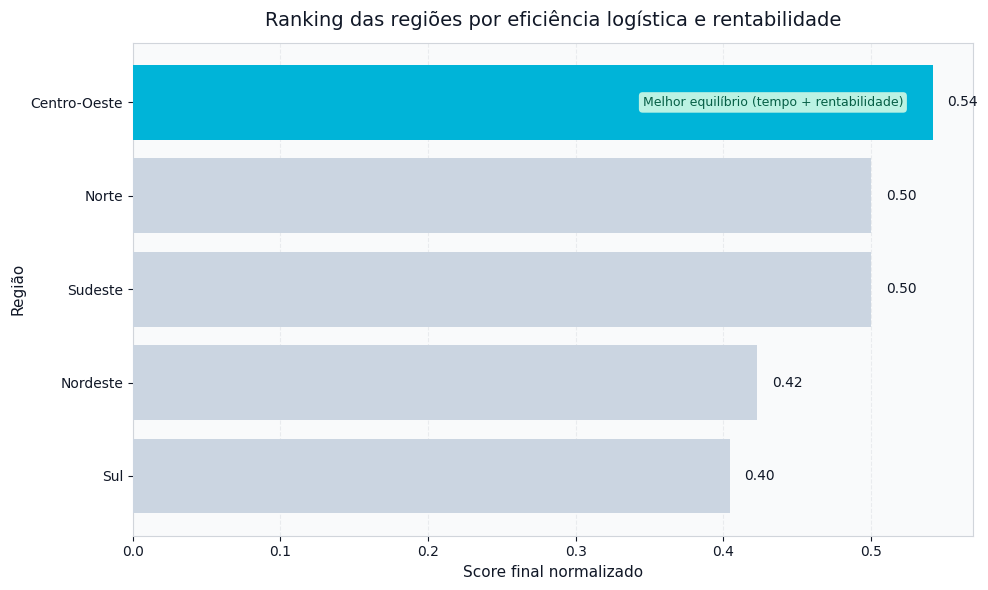


O ranking final evidencia que a região Centro-Oeste apresenta o melhor equilíbrio
entre tempo de entrega e rentabilidade, liderando o score combinado. Embora não
possua o menor tempo nem a maior rentabilidade isoladamente, seu desempenho
consistente nas duas dimensões garante a melhor posição geral.

Por outro lado, o Sudeste se destaca pela eficiência logística, enquanto o Norte
apresenta maior rentabilidade média. Esses resultados reforçam a existência de
um possível trade-off entre velocidade de entrega e retorno financeiro.



In [736]:
# ============================================================
# 17. BARPLOT DO SCORE FINAL (REGIÃO)
# ============================================================

# ------------------------------------------------------------
# Preparar dados para o gráfico
# ------------------------------------------------------------
dados_plot = analise_score.sort_values("score_final", ascending=True)

# Identificar a região com maior score final.
# Essa região representa o melhor equilíbrio entre tempo de entrega e rentabilidade.
melhor_regiao = dados_plot.iloc[-1]["regiao"]

# ------------------------------------------------------------
# Definir cores das barras
# ------------------------------------------------------------
# A melhor região recebe cor de destaque.
# As demais regiões ficam em tom neutro para criar hierarquia visual.
cores = [
    "#00B4D8" if regiao == melhor_regiao else "#CBD5E1"
    for regiao in dados_plot["regiao"]
]

# ------------------------------------------------------------
# Criar figura e eixo
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plotar gráfico de barras horizontal
# ------------------------------------------------------------
# Cada barra representa o score final normalizado de uma região.
bars = ax.barh(
    dados_plot["regiao"],
    dados_plot["score_final"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e rótulos dos eixos
# ------------------------------------------------------------
ax.set_title(
    "Ranking das regiões por eficiência logística e rentabilidade",
    color=cor_texto,
    fontsize=14,
    pad=12
)

ax.set_xlabel("Score final normalizado", color=cor_texto)
ax.set_ylabel("Região", color=cor_texto)

# ------------------------------------------------------------
# Grade e eixos
# ------------------------------------------------------------
# A grade no eixo X facilita comparar visualmente os scores.
ax.grid(axis="x", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

# ------------------------------------------------------------
# Adicionar valores ao final das barras
# ------------------------------------------------------------
# Os valores tornam o ranking mais claro e evitam depender apenas da leitura visual.
for bar in bars:
    largura = bar.get_width()

    ax.text(
        largura + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{largura:.2f}",
        va="center",
        ha="left",
        color=cor_texto,
        fontsize=10
    )

# ------------------------------------------------------------
# Destaque textual da melhor região
# ------------------------------------------------------------
# O selo destaca a região líder no score combinado.
# A posição é calculada com base na própria barra para evitar desalinhamento.
for bar, regiao in zip(bars, dados_plot["regiao"]):
    if regiao == melhor_regiao:
        largura = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        ax.text(
            largura - 0.02,
            y_pos,
            "Melhor equilíbrio (tempo + rentabilidade)",
            va="center",
            ha="right",
            fontsize=9,
            color="#065F46",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#D1FAE5",
                edgecolor="none",
                alpha=0.9
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Bordas
# ------------------------------------------------------------
# Mantemos bordas suaves para combinar com o tema claro do projeto.
for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

print("""
O ranking final evidencia que a região Centro-Oeste apresenta o melhor equilíbrio
entre tempo de entrega e rentabilidade, liderando o score combinado. Embora não
possua o menor tempo nem a maior rentabilidade isoladamente, seu desempenho
consistente nas duas dimensões garante a melhor posição geral.

Por outro lado, o Sudeste se destaca pela eficiência logística, enquanto o Norte
apresenta maior rentabilidade média. Esses resultados reforçam a existência de
um possível trade-off entre velocidade de entrega e retorno financeiro.
""")

In [737]:
print("""
--- ANÁLISE POR REGIÃO CONCLUSIVA ---

A análise por região evidencia diferenças relevantes entre desempenho logístico e rentabilidade
ao longo do território nacional.

A região Sudeste apresenta o menor tempo médio de entrega e menor variabilidade, indicando maior
eficiência e previsibilidade logística. Esse comportamento é consistente com a maior concentração
de pedidos e volume operacional observado na região.

Por outro lado, regiões como Norte e Nordeste apresentam tempos médios de entrega mais elevados e maior
dispersão, sugerindo menor eficiência logística e maior variabilidade no processo de entrega.

Em relação à rentabilidade, observa-se que, nos dados analisados, regiões com maior tempo de entrega,
como Norte e Centro-Oeste, apresentam valores médios superiores, enquanto regiões mais eficientes
logisticamente apresentam menor rentabilidade média.

Esse comportamento indica a existência de um possível trade-off entre eficiência logística e rentabilidade,
onde ganhos em velocidade de entrega não necessariamente implicam maior retorno médio por pedido.

No entanto, essa relação deve ser interpretada com cautela, pois não implica causalidade direta, podendo
estar associada a fatores estruturais, como características de demanda, distribuição geográfica ou dinâmica
de preços. Além disso, a rentabilidade utilizada nesta análise é uma proxy baseada em receita menos frete,
não representando o lucro contábil completo.

Como nenhuma região lidera simultaneamente nas duas dimensões analisadas, foi construído um score combinado,
considerando igualmente o tempo de entrega e a rentabilidade. Com base nesse critério, a região Centro-Oeste
apresenta o melhor equilíbrio entre eficiência logística e retorno financeiro.

Do ponto de vista de negócio, os resultados sugerem que:

- O Sudeste deve ser priorizado para estratégias de eficiência operacional e melhoria da experiência do cliente
- O Centro-Oeste representa o melhor equilíbrio entre custo logístico e retorno financeiro
- Regiões com maior tempo de entrega apresentam oportunidades relevantes de melhoria logística

Essa análise reforça a importância de considerar múltiplas dimensões na avaliação de desempenho regional,
evitando decisões baseadas em uma única métrica.
""")


--- ANÁLISE POR REGIÃO CONCLUSIVA ---

A análise por região evidencia diferenças relevantes entre desempenho logístico e rentabilidade
ao longo do território nacional.

A região Sudeste apresenta o menor tempo médio de entrega e menor variabilidade, indicando maior
eficiência e previsibilidade logística. Esse comportamento é consistente com a maior concentração
de pedidos e volume operacional observado na região.

Por outro lado, regiões como Norte e Nordeste apresentam tempos médios de entrega mais elevados e maior
dispersão, sugerindo menor eficiência logística e maior variabilidade no processo de entrega.

Em relação à rentabilidade, observa-se que, nos dados analisados, regiões com maior tempo de entrega,
como Norte e Centro-Oeste, apresentam valores médios superiores, enquanto regiões mais eficientes
logisticamente apresentam menor rentabilidade média.

Esse comportamento indica a existência de um possível trade-off entre eficiência logística e rentabilidade,
onde ganhos em veloc

In [738]:
# ============================================================
# 19. ANÁLISE POR ESTADO (APROFUNDAMENTO)
# ============================================================

# Objetivo desta etapa:
# - Entender quais estados explicam o desempenho das regiões
# - Identificar diferenças internas dentro de cada região
# - Transformar análise descritiva em análise diagnóstica

analise_estado = (
    df_limpo
    # Agrupar por região e estado
    .groupby(["regiao", "customer_state"], as_index=False)
    
    # Calcular métricas relevantes
    .agg(
        # Número de pedidos únicos
        pedidos=("order_id", "nunique"),
        
        # Receita total agregada
        receita_total=("receita_total", "sum"),
        
        # Tempo médio de entrega (sensível a outliers)
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        
        # Mediana (mais robusta para distribuição assimétrica)
        tempo_entrega_mediano=("tempo_entrega_dias", "median"),
        
        # Desvio padrão (mede variabilidade/logística)
        tempo_std=("tempo_entrega_dias", "std"),
        
        # Rentabilidade média por pedido
        rentabilidade_media=("rentabilidade_proxy", "mean"),
        
        # Margem percentual média
        margem_media_pct=("margem_proxy_pct", "mean"),
        
        # Taxa de entrega no prazo (proporção)
        taxa_no_prazo=("entrega_no_prazo", "mean")
    )
)

# Converter taxa de proporção (0-1) para percentual (0-100)
analise_estado["taxa_no_prazo"] = analise_estado["taxa_no_prazo"] * 100

print("\n--- ANÁLISE POR ESTADO ---")
display(analise_estado.sort_values(["regiao", "tempo_entrega_medio"]))


--- ANÁLISE POR ESTADO ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
0,Centro-Oeste,DF,2080,296498.41,12.509135,11.0,7.060578,118.689168,66.570296,94.326923
1,Centro-Oeste,GO,1957,282836.70,15.150741,13.0,9.287240,118.273403,65.766958,93.459377
2,Centro-Oeste,MS,701,115429.97,15.191155,13.0,7.739729,137.649629,66.309551,90.299572
3,Centro-Oeste,MT,886,152191.62,17.593679,16.0,8.501361,139.005440,62.352927,94.018059
9,Nordeste,PE,1593,251889.49,17.965474,15.0,10.951558,122.289347,56.633518,90.395480
11,Nordeste,RN,474,82105.66,18.824895,16.0,12.994914,133.958945,50.600560,90.717300
5,Nordeste,BA,3256,493584.14,18.866400,16.0,11.695508,121.630980,61.452348,87.837838
10,Nordeste,PI,476,84721.00,18.993697,16.0,14.718194,135.008004,49.707768,86.134454
8,Nordeste,PB,517,112586.82,19.953578,18.0,10.944972,168.926673,50.158078,89.555126
6,Nordeste,CE,1279,219757.38,20.817826,18.0,13.123303,135.322901,57.327509,86.239249


In [739]:
# ============================================================
# 20. FILTRO DE REPRESENTATIVIDADE
# ============================================================

# Problema:
# Estados com poucos pedidos podem distorcer a análise

# Solução:
# Definir um mínimo de pedidos para garantir confiabilidade

limite = analise_estado["pedidos"].quantile(0.25)

analise_estado_filtrado = analise_estado[
    analise_estado["pedidos"] >= limite
]

print(f"\nDesconsiderado 25% menores estados:")
display(analise_estado_filtrado.sort_values("tempo_entrega_medio"))
print("""
      Para garantir maior robustez estatística, foi aplicado um critério mínimo de volume de pedidos na análise por estado. 
      Em vez de utilizar um valor arbitrário fixo, adotou-se um filtro baseado na distribuição dos dados, reduzindo o impacto
      de estados com baixa representatividade, que poderiam distorcer os resultados.
      """)


Desconsiderado 25% menores estados:


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
23,Sudeste,SP,40494,5066562.98,8.298094,7.0,6.759810,107.784060,74.853434,95.505507
24,Sul,PR,4923,666063.51,11.526711,10.0,6.985404,111.805448,66.531711,95.957749
21,Sudeste,MG,11354,1552481.83,11.542188,10.0,7.204126,113.270388,68.417153,95.428924
0,Centro-Oeste,DF,2080,296498.41,12.509135,11.0,7.060578,118.689168,66.570296,94.326923
26,Sul,SC,3546,507012.13,14.475183,13.0,8.581745,118.132115,66.984156,91.793570
25,Sul,RS,5344,728718.47,14.819237,13.0,9.180509,111.556540,66.093887,93.918413
22,Sudeste,RJ,12350,1759651.13,14.848583,12.0,11.530814,118.534469,68.436596,87.894737
1,Centro-Oeste,GO,1957,282836.70,15.150741,13.0,9.287240,118.273403,65.766958,93.459377
2,Centro-Oeste,MS,701,115429.97,15.191155,13.0,7.739729,137.649629,66.309551,90.299572
20,Sudeste,ES,1995,268643.45,15.331830,13.0,10.646653,110.089709,65.376718,89.273183



      Para garantir maior robustez estatística, foi aplicado um critério mínimo de volume de pedidos na análise por estado. 
      Em vez de utilizar um valor arbitrário fixo, adotou-se um filtro baseado na distribuição dos dados, reduzindo o impacto
      de estados com baixa representatividade, que poderiam distorcer os resultados.
      


In [740]:
# ============================================================
# 21. RANKING DE ESTADOS
# ============================================================

# Critério:
# - menor tempo de entrega (prioridade)
# - maior rentabilidade (desempate)

melhores_estados = analise_estado_filtrado.sort_values(
    by=["tempo_entrega_medio", "rentabilidade_media"],
    ascending=[True, False]
)

print("\n--- TOP ESTADOS (EFICIÊNCIA + RENTABILIDADE) ---")
display(melhores_estados.head(10))


--- TOP ESTADOS (EFICIÊNCIA + RENTABILIDADE) ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
23,Sudeste,SP,40494,5066562.98,8.298094,7.0,6.759810,107.784060,74.853434,95.505507
24,Sul,PR,4923,666063.51,11.526711,10.0,6.985404,111.805448,66.531711,95.957749
21,Sudeste,MG,11354,1552481.83,11.542188,10.0,7.204126,113.270388,68.417153,95.428924
0,Centro-Oeste,DF,2080,296498.41,12.509135,11.0,7.060578,118.689168,66.570296,94.326923
26,Sul,SC,3546,507012.13,14.475183,13.0,8.581745,118.132115,66.984156,91.793570
25,Sul,RS,5344,728718.47,14.819237,13.0,9.180509,111.556540,66.093887,93.918413
22,Sudeste,RJ,12350,1759651.13,14.848583,12.0,11.530814,118.534469,68.436596,87.894737
1,Centro-Oeste,GO,1957,282836.70,15.150741,13.0,9.287240,118.273403,65.766958,93.459377
2,Centro-Oeste,MS,701,115429.97,15.191155,13.0,7.739729,137.649629,66.309551,90.299572
20,Sudeste,ES,1995,268643.45,15.331830,13.0,10.646653,110.089709,65.376718,89.273183


In [741]:
# ============================================================
# 22. ANÁLISE INTERNA POR REGIÃO
# ============================================================

# Objetivo:
# Ver quais estados "puxam" o resultado de cada região

for regiao in analise_estado_filtrado["regiao"].unique():
    
    print(f"\n--- Região: {regiao} ---")
    
    # Filtrar estados da região
    df_regiao = analise_estado_filtrado[
        analise_estado_filtrado["regiao"] == regiao
    ]
    
    # Ordenar por tempo de entrega
    display(df_regiao.sort_values("tempo_entrega_medio"))


--- Região: Centro-Oeste ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
0,Centro-Oeste,DF,2080,296498.41,12.509135,11.0,7.060578,118.689168,66.570296,94.326923
1,Centro-Oeste,GO,1957,282836.70,15.150741,13.0,9.287240,118.273403,65.766958,93.459377
2,Centro-Oeste,MS,701,115429.97,15.191155,13.0,7.739729,137.649629,66.309551,90.299572
3,Centro-Oeste,MT,886,152191.62,17.593679,16.0,8.501361,139.005440,62.352927,94.018059



--- Região: Nordeste ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
9,Nordeste,PE,1593,251889.49,17.965474,15.0,10.951558,122.289347,56.633518,90.395480
11,Nordeste,RN,474,82105.66,18.824895,16.0,12.994914,133.958945,50.600560,90.717300
5,Nordeste,BA,3256,493584.14,18.866400,16.0,11.695508,121.630980,61.452348,87.837838
10,Nordeste,PI,476,84721.00,18.993697,16.0,14.718194,135.008004,49.707768,86.134454
8,Nordeste,PB,517,112586.82,19.953578,18.0,10.944972,168.926673,50.158078,89.555126
6,Nordeste,CE,1279,219757.38,20.817826,18.0,13.123303,135.322901,57.327509,86.239249
7,Nordeste,MA,717,117009.38,21.117155,19.0,11.365202,120.244365,46.275047,82.566248
4,Nordeste,AL,397,78855.72,24.040302,22.0,11.480919,160.047733,53.172914,78.589421



--- Região: Norte ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
16,Norte,PA,946,174470.59,23.316068,21.0,13.163783,144.733203,53.723905,88.794926



--- Região: Sudeste ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
23,Sudeste,SP,40494,5066562.98,8.298094,7.0,6.759810,107.784060,74.853434,95.505507
21,Sudeste,MG,11354,1552481.83,11.542188,10.0,7.204126,113.270388,68.417153,95.428924
22,Sudeste,RJ,12350,1759651.13,14.848583,12.0,11.530814,118.534469,68.436596,87.894737
20,Sudeste,ES,1995,268643.45,15.331830,13.0,10.646653,110.089709,65.376718,89.273183



--- Região: Sul ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo
24,Sul,PR,4923,666063.51,11.526711,10.0,6.985404,111.805448,66.531711,95.957749
26,Sul,SC,3546,507012.13,14.475183,13.0,8.581745,118.132115,66.984156,91.793570
25,Sul,RS,5344,728718.47,14.819237,13.0,9.180509,111.556540,66.093887,93.918413


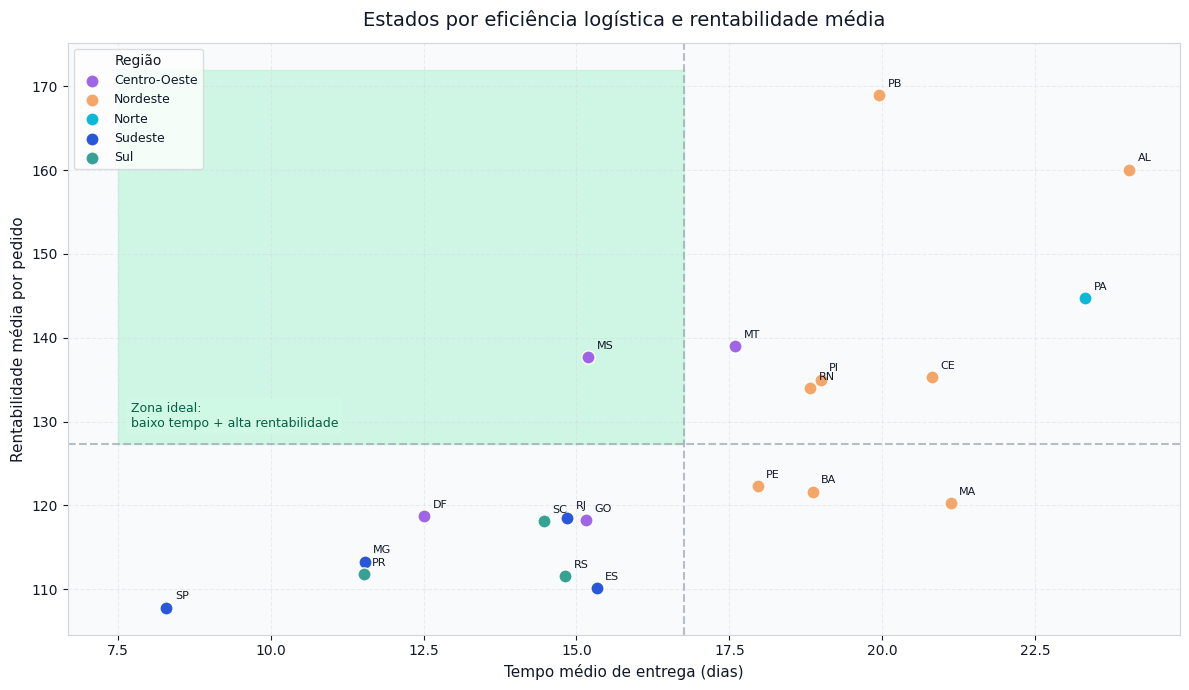


O gráfico evidencia a dispersão dos estados entre eficiência logística e rentabilidade média.
Estados do Sudeste aparecem mais concentrados em menores tempos de entrega, enquanto estados
do Norte e parte do Nordeste se posicionam em faixas de maior rentabilidade, porém com tempos
logísticos mais elevados.

Esse comportamento sugere um possível trade-off entre agilidade operacional e retorno médio
por pedido, reforçando a importância de analisar o desempenho em nível estadual, e não apenas
regional.



In [742]:
# ============================================================
# 23. GRÁFICO: TEMPO VS RENTABILIDADE POR ESTADO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------
# Plotar pontos por região
# ------------------------------
for regiao, df_regiao in analise_estado_filtrado.groupby("regiao"):
    ax.scatter(
        df_regiao["tempo_entrega_medio"],
        df_regiao["rentabilidade_media"],
        s=90,
        color=cores_regiao.get(regiao, "#9CA3AF"),
        edgecolor="#FFFFFF",
        linewidth=1.0,
        alpha=0.95,
        label=regiao,
        zorder=3
    )

# ------------------------------
# Labels dos estados
# ------------------------------
for _, row in analise_estado_filtrado.iterrows():
    ax.annotate(
        row["customer_state"],
        (row["tempo_entrega_medio"], row["rentabilidade_media"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color=cor_texto
    )

# ------------------------------
# Linhas médias
# ------------------------------
media_tempo = analise_estado_filtrado["tempo_entrega_medio"].mean()
media_rent = analise_estado_filtrado["rentabilidade_media"].mean()

ax.axvline(media_tempo, linestyle="--", color="#9CA3AF", alpha=0.7)
ax.axhline(media_rent, linestyle="--", color="#9CA3AF", alpha=0.7)

# ------------------------------
# Zona ideal: baixo tempo + alta rentabilidade
# ------------------------------
y_min, y_max = ax.get_ylim()
x_min, x_max = ax.get_xlim()

ax.fill_betweenx(
    [media_rent, y_max],
    x_min,
    media_tempo,
    color="#A7F3D0",
    alpha=0.5,
    zorder=0
)

ax.text(
    x=x_min + 0.2,
    y=media_rent + 2,
    s="Zona ideal:\nbaixo tempo + alta rentabilidade",
    fontsize=9,
    color="#065F46",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#D1FAE5",
        edgecolor="none",
        alpha=0.9
    )
)

# ------------------------------
# Título e eixos
# ------------------------------
ax.set_title(
    "Estados por eficiência logística e rentabilidade média",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Tempo médio de entrega (dias)", color=cor_texto)
ax.set_ylabel("Rentabilidade média por pedido", color=cor_texto)

# ------------------------------
# Grid e estilo
# ------------------------------
ax.grid(True, linestyle="--", alpha=0.4, color=cor_grid)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

# ------------------------------
# Legenda por região
# ------------------------------
leg = ax.legend(
    title="Região",
    loc="upper left",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor=cor_grid,
    fontsize=9,
    title_fontsize=10
)

# melhorar contraste do texto
for text in leg.get_texts():
    text.set_color("#111827")

leg.get_title().set_color("#111827")

plt.tight_layout()
plt.show()

print("""
O gráfico evidencia a dispersão dos estados entre eficiência logística e rentabilidade média.
Estados do Sudeste aparecem mais concentrados em menores tempos de entrega, enquanto estados
do Norte e parte do Nordeste se posicionam em faixas de maior rentabilidade, porém com tempos
logísticos mais elevados.

Esse comportamento sugere um possível trade-off entre agilidade operacional e retorno médio
por pedido, reforçando a importância de analisar o desempenho em nível estadual, e não apenas
regional.
""")

In [743]:
# ============================================================
# 24. NORMALIZAR MÉTRICAS PARA CRIAR SCORE FINAL POR ESTADO
# ============================================================

# Criar cópia da base de estados filtrados
analise_estado_score = analise_estado_filtrado.copy()

# ------------------------------------------------------------
# 24.1 Score de tempo
# ------------------------------------------------------------
# Como menor tempo de entrega é melhor,
# usamos normalização min-max invertida.
# Assim, o menor tempo recebe score mais alto.
analise_estado_score["score_tempo"] = (
    analise_estado_score["tempo_entrega_medio"].max() - analise_estado_score["tempo_entrega_medio"]
) / (
    analise_estado_score["tempo_entrega_medio"].max() - analise_estado_score["tempo_entrega_medio"].min()
)

# ------------------------------------------------------------
# 24.2 Score de rentabilidade
# ------------------------------------------------------------
# Como maior rentabilidade é melhor,
# usamos normalização min-max tradicional.
# Assim, a maior rentabilidade recebe score mais alto.
analise_estado_score["score_rentabilidade"] = (
    analise_estado_score["rentabilidade_media"] - analise_estado_score["rentabilidade_media"].min()
) / (
    analise_estado_score["rentabilidade_media"].max() - analise_estado_score["rentabilidade_media"].min()
)

# ------------------------------------------------------------
# 24.3 Score final bruto
# ------------------------------------------------------------
# Aqui damos pesos iguais:
# 50% para tempo de entrega
# 50% para rentabilidade
analise_estado_score["score_final"] = (
    0.5 * analise_estado_score["score_tempo"] +
    0.5 * analise_estado_score["score_rentabilidade"]
)

# ------------------------------------------------------------
# 24.4 Peso de confiança da amostra
# ------------------------------------------------------------
# Estados com mais pedidos tendem a ter métricas mais estáveis.
# Por isso, criamos um peso com base no volume de pedidos.
#
# Usamos raiz quadrada para aplicar uma penalização suave:
# - estados com poucos pedidos perdem força
# - mas não são totalmente excluídos da análise
analise_estado_score["peso_amostra"] = (
    analise_estado_score["pedidos"] / analise_estado_score["pedidos"].max()
) ** 0.5

# ------------------------------------------------------------
# 24.5 Score final ajustado por amostra
# ------------------------------------------------------------
# O score final ajustado combina desempenho e confiabilidade.
analise_estado_score["score_final_ajustado"] = (
    analise_estado_score["score_final"] * analise_estado_score["peso_amostra"]
)

# Ordenar do melhor para o pior
analise_estado_score = analise_estado_score.sort_values(
    "score_final_ajustado", ascending=False
)

print("\n--- RANKING FINAL POR ESTADO (AJUSTADO POR AMOSTRA) ---")
display(analise_estado_score.head(10))


--- RANKING FINAL POR ESTADO (AJUSTADO POR AMOSTRA) ---


,regiao,customer_state,pedidos,receita_total,tempo_entrega_medio,tempo_entrega_mediano,tempo_std,rentabilidade_media,margem_media_pct,taxa_no_prazo,score_tempo,score_rentabilidade,score_final,peso_amostra,score_final_ajustado
23,Sudeste,SP,40494,5066562.98,8.298094,7.0,6.759810,107.784060,74.853434,95.505507,1.000000,0.000000,0.500000,1.000000,0.500000
21,Sudeste,MG,11354,1552481.83,11.542188,10.0,7.204126,113.270388,68.417153,95.428924,0.793924,0.089730,0.441827,0.529516,0.233954
22,Sudeste,RJ,12350,1759651.13,14.848583,12.0,11.530814,118.534469,68.436596,87.894737,0.583890,0.175825,0.379858,0.552253,0.209778
24,Sul,PR,4923,666063.51,11.526711,10.0,6.985404,111.805448,66.531711,95.957749,0.794907,0.065771,0.430339,0.348674,0.150048
25,Sul,RS,5344,728718.47,14.819237,13.0,9.180509,111.556540,66.093887,93.918413,0.585754,0.061700,0.323727,0.363277,0.117603
26,Sul,SC,3546,507012.13,14.475183,13.0,8.581745,118.132115,66.984156,91.793570,0.607610,0.169245,0.388427,0.295920,0.114943
0,Centro-Oeste,DF,2080,296498.41,12.509135,11.0,7.060578,118.689168,66.570296,94.326923,0.732500,0.178355,0.455428,0.226640,0.103218
1,Centro-Oeste,GO,1957,282836.70,15.150741,13.0,9.287240,118.273403,65.766958,93.459377,0.564696,0.171555,0.368126,0.219837,0.080928
5,Nordeste,BA,3256,493584.14,18.866400,16.0,11.695508,121.630980,61.452348,87.837838,0.328664,0.226469,0.277567,0.283561,0.078707
8,Nordeste,PB,517,112586.82,19.953578,18.0,10.944972,168.926673,50.158078,89.555126,0.259603,1.000000,0.629801,0.112993,0.071163


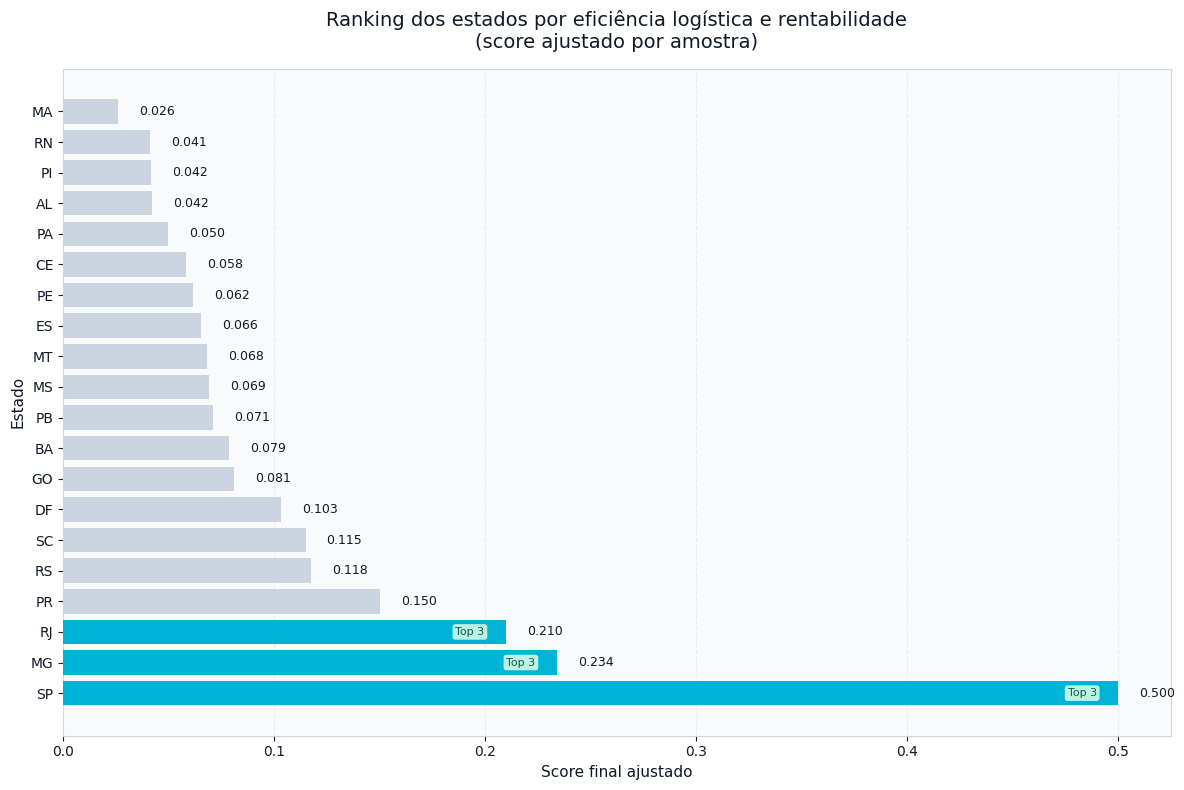


O ranking por estado foi construído com base em um score que combina tempo médio de entrega
e rentabilidade média, ajustado por volume de pedidos. Esse ajuste reduz o efeito de estados
com baixa representatividade, tornando a comparação mais robusta.

Assim, os estados no topo do ranking não são apenas eficientes e rentáveis, mas também
apresentam maior confiabilidade analítica. A leitura do ranking deve considerar que o score
ajustado combina desempenho operacional, retorno financeiro e representatividade da amostra.



In [744]:
# ============================================================
# 25. BARPLOT DO SCORE FINAL AJUSTADO POR ESTADO
# ============================================================

# ------------------------------------------------------------
# Preparar dados para o gráfico
# ------------------------------------------------------------
# Ordenamos do menor para o maior score.
# Como o gráfico é horizontal, depois usamos invert_yaxis()
# para deixar os estados com maior score no topo.
dados_plot = analise_estado_score.sort_values(
    "score_final_ajustado",
    ascending=True
).copy()

# ------------------------------------------------------------
# Identificar top 3 estados
# ------------------------------------------------------------
# Os três maiores scores serão destacados visualmente.
top3_indices = dados_plot["score_final_ajustado"].nlargest(3).index

# Cores no padrão visual claro do projeto:
# - Top 3 em destaque
# - Demais estados em tom neutro
cores = [
    "#00B4D8" if idx in top3_indices else "#CBD5E1"
    for idx in dados_plot.index
]

# ------------------------------------------------------------
# Criar figura e eixo
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plotar gráfico de barras horizontal
# ------------------------------------------------------------
# Cada barra representa o score final ajustado por amostra de um estado.
bars = ax.barh(
    dados_plot["customer_state"],
    dados_plot["score_final_ajustado"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e rótulos dos eixos
# ------------------------------------------------------------
ax.set_title(
    "Ranking dos estados por eficiência logística e rentabilidade\n(score ajustado por amostra)",
    color=cor_texto,
    fontsize=14,
    pad=15
)

ax.set_xlabel("Score final ajustado", color=cor_texto, fontsize=11)
ax.set_ylabel("Estado", color=cor_texto, fontsize=11)

# ------------------------------------------------------------
# Grade e eixos
# ------------------------------------------------------------
# A grade no eixo X facilita comparar os scores entre estados.
ax.grid(axis="x", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

# ------------------------------------------------------------
# Adicionar valores ao final das barras
# ------------------------------------------------------------
# Os valores ajudam a interpretar a diferença entre os estados.
for bar in bars:
    largura = bar.get_width()

    ax.text(
        largura + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{largura:.3f}",
        va="center",
        ha="left",
        color=cor_texto,
        fontsize=9
    )

# ------------------------------------------------------------
# Destacar top 3 estados
# ------------------------------------------------------------
# O selo reforça visualmente quais estados lideram o ranking ajustado.
for bar, idx in zip(bars, dados_plot.index):
    if idx in top3_indices:
        largura = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        ax.text(
            largura - 0.01,
            y_pos,
            "Top 3",
            va="center",
            ha="right",
            fontsize=8,
            color="#065F46",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#D1FAE5",
                edgecolor="none",
                alpha=0.9
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Bordas
# ------------------------------------------------------------
# Mantemos bordas suaves para seguir o padrão visual claro do projeto.
for spine in ax.spines.values():
    spine.set_color(cor_grid)

# Melhor estado no topo do gráfico
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("""
O ranking por estado foi construído com base em um score que combina tempo médio de entrega
e rentabilidade média, ajustado por volume de pedidos. Esse ajuste reduz o efeito de estados
com baixa representatividade, tornando a comparação mais robusta.

Assim, os estados no topo do ranking não são apenas eficientes e rentáveis, mas também
apresentam maior confiabilidade analítica. A leitura do ranking deve considerar que o score
ajustado combina desempenho operacional, retorno financeiro e representatividade da amostra.
""")

In [745]:
print("""
--- ANÁLISE DIAGNÓSTICA POR ESTADO ---

A análise por estado permite aprofundar o entendimento dos resultados observados nas regiões,
evidenciando diferenças relevantes dentro de uma mesma região e identificando padrões específicos
de desempenho logístico e rentabilidade.

Observa-se que o Sudeste apresenta os melhores indicadores de eficiência logística, com destaque
para o estado de São Paulo, que possui o menor tempo médio de entrega entre todos os estados
analisados. Minas Gerais também apresenta bom desempenho, reforçando a consistência da região.

A região Sul demonstra comportamento equilibrado, com estados apresentando tempos de entrega
moderados e baixa variabilidade, indicando uma operação logística relativamente estável.

Por outro lado, regiões como Norte e Nordeste apresentam maiores tempos de entrega e maior
dispersão dos dados, sugerindo menor previsibilidade logística. Ainda assim, estados como Paraíba (PB)
e Alagoas (AL) apresentam rentabilidade média elevada, reforçando a existência de um trade-off entre
eficiência logística e retorno financeiro.

A análise também evidencia que o desempenho regional não é homogêneo, sendo influenciado por
estados específicos. No Centro-Oeste, por exemplo, o Distrito Federal apresenta melhor desempenho
logístico em comparação a outros estados da mesma região.

Para garantir maior robustez estatística, foi aplicado um critério mínimo de volume de pedidos,
reduzindo o impacto de estados com baixa representatividade. Além disso, o ranking foi ajustado
por um fator de confiança baseado no volume de pedidos, penalizando suavemente estados com menor
amostra e tornando a comparação mais consistente.

Com base nesse critério, o score final ajustado permite identificar os estados com melhor equilíbrio
entre eficiência logística e rentabilidade, evitando distorções causadas por médias extremas.

Do ponto de vista de negócio, os resultados indicam que:

- Estados com menor tempo de entrega são estratégicos para melhorar a experiência do cliente
- Estados com maior rentabilidade podem representar oportunidades de expansão, mesmo com desafios logísticos
- A análise em nível de estado permite decisões mais precisas do que a visão agregada por região
- Estados com baixa representatividade devem ser interpretados com cautela

Esses achados reforçam a importância de análises em múltiplos níveis e do uso de métricas ajustadas
para apoiar decisões estratégicas mais robustas e confiáveis.
""")


--- ANÁLISE DIAGNÓSTICA POR ESTADO ---

A análise por estado permite aprofundar o entendimento dos resultados observados nas regiões,
evidenciando diferenças relevantes dentro de uma mesma região e identificando padrões específicos
de desempenho logístico e rentabilidade.

Observa-se que o Sudeste apresenta os melhores indicadores de eficiência logística, com destaque
para o estado de São Paulo, que possui o menor tempo médio de entrega entre todos os estados
analisados. Minas Gerais também apresenta bom desempenho, reforçando a consistência da região.

A região Sul demonstra comportamento equilibrado, com estados apresentando tempos de entrega
moderados e baixa variabilidade, indicando uma operação logística relativamente estável.

Por outro lado, regiões como Norte e Nordeste apresentam maiores tempos de entrega e maior
dispersão dos dados, sugerindo menor previsibilidade logística. Ainda assim, estados como Paraíba (PB)
e Alagoas (AL) apresentam rentabilidade média elevada, reforça